In [13]:
import os
import sys
notebook_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(notebook_dir, ".."))

if project_root not in sys.path:
    sys.path.append(project_root)
    sys.path.append(os.path.join(project_root, 'src'))
%load_ext autoreload
%autoreload 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
import pandas as pd
from src.eda_pipeline import EDAPipeline, EDAConfig

In [15]:
df=pd.read_csv('../data/raw/data.csv')
df.head()

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


2026-05-31 20:32:20,005 - INFO - EDAPipeline initialized. Output directory: c:\Users\Hello\Desktop\kaim\credit-risk-model\outputs\eda_run_20260531_203220
2026-05-31 20:32:20,029 - INFO - ✅ Data loaded: 95,662 rows × 16 columns
2026-05-31 20:32:20,031 - INFO -  Starting EDA Pipeline...
2026-05-31 20:32:21,653 - INFO -  Generating visualizations...



		DATA OVERVIEW
Dataset Shape     : 95662 rows × 16 columns
Memory Usage      : 74.51 MB


SUMMARY STATISTICS (Numerical Features) 

                      mean  median          std     skew   kurtosis  \
CountryCode       256.0000   256.0       0.0000   0.0000     0.0000   
Amount           6717.8464  1000.0  123306.7972  51.0985  3363.1277   
Value            9900.5839  1000.0  123122.0878  51.2911  3378.0693   
PricingStrategy     2.2560     2.0       0.7329   1.6591     2.0875   
FraudResult         0.0020     0.0       0.0449  22.1963   490.6858   

                                                           insight  
CountryCode                                              Symmetric  
Amount           Highly right-skewed (skew=51.10) | Leptokurtic...  
Value            Highly right-skewed (skew=51.29) | Leptokurtic...  
PricingStrategy                    Highly right-skewed (skew=1.66)  
FraudResult      Highly right-skewed (skew=22.20) | Leptokurtic...  

SUMMARY STATISTICS (Cate

2026-05-31 20:32:21,893 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-31 20:32:22,014 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


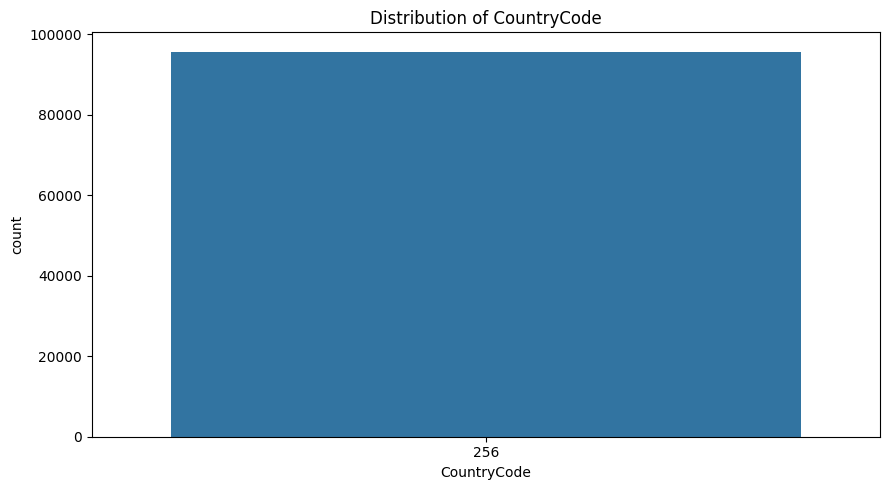

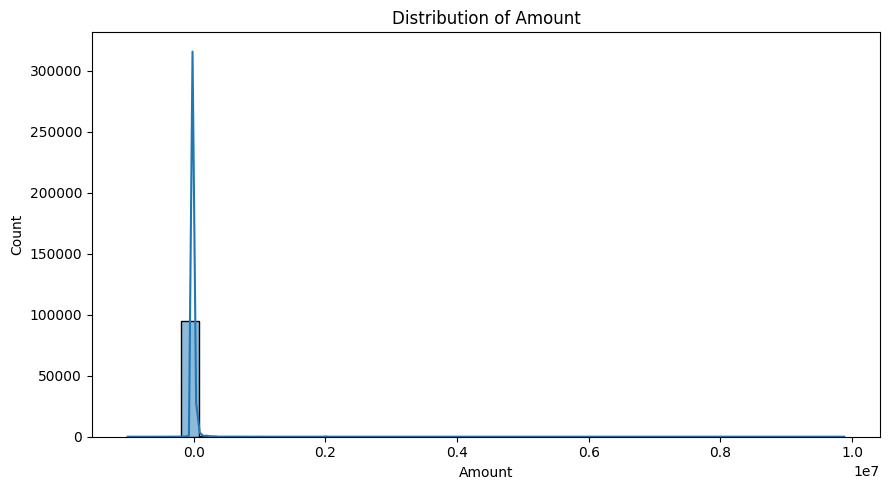

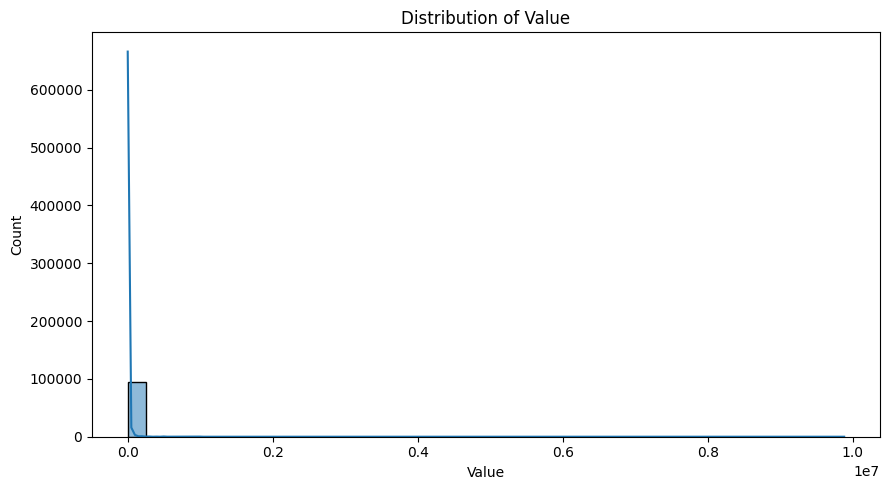

2026-05-31 20:32:27,192 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-31 20:32:27,295 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


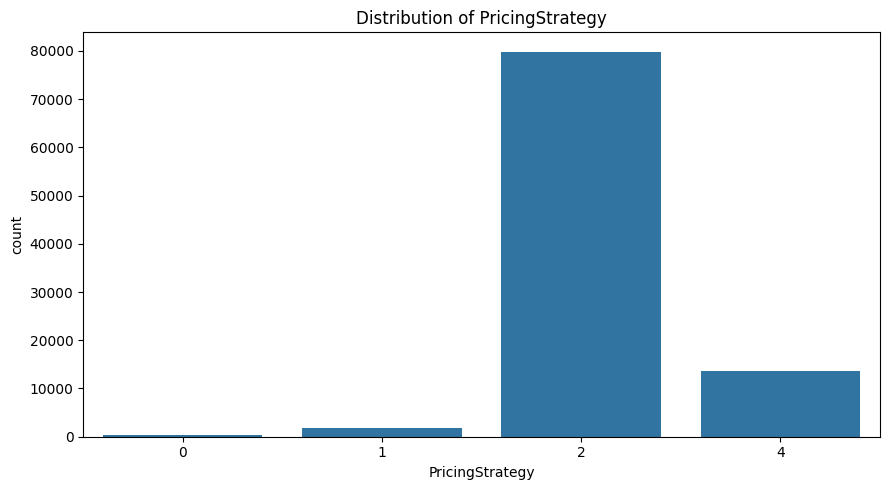

2026-05-31 20:32:28,264 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-31 20:32:28,368 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


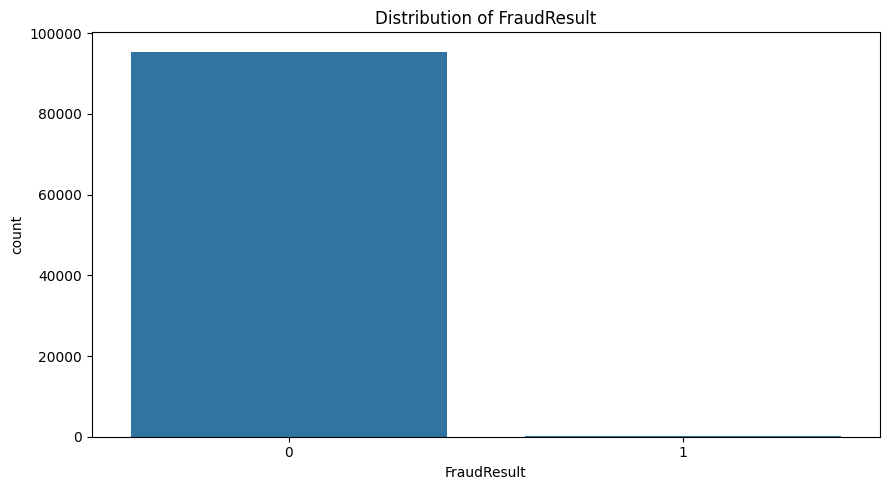

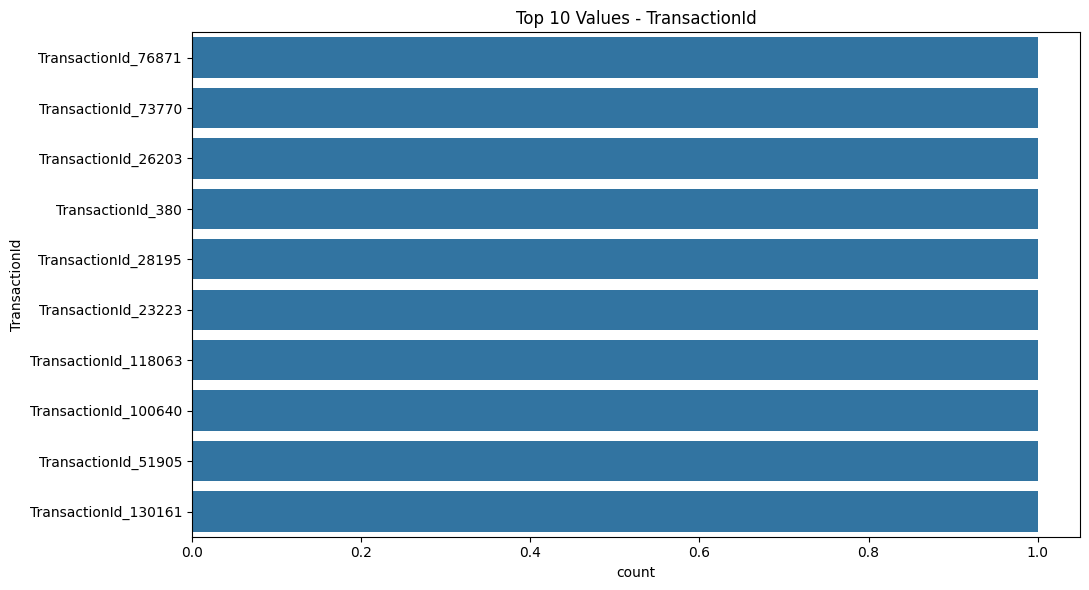

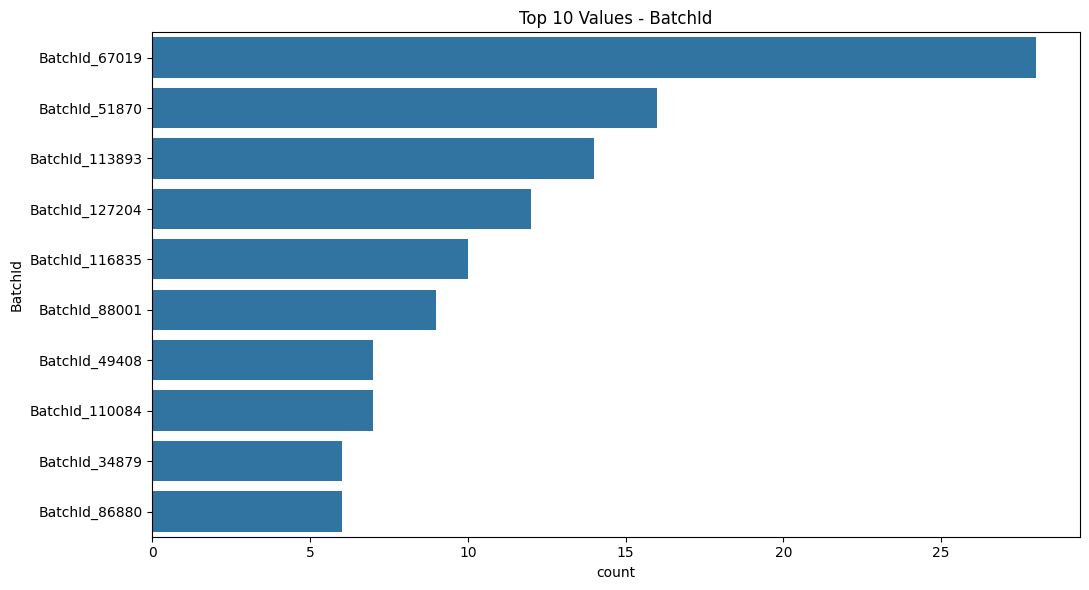

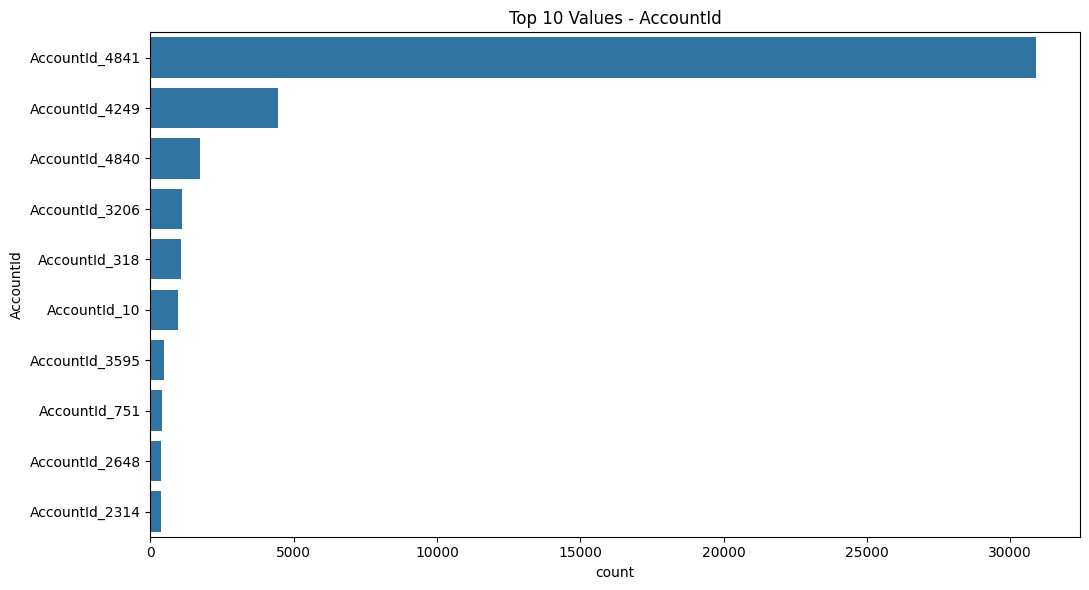

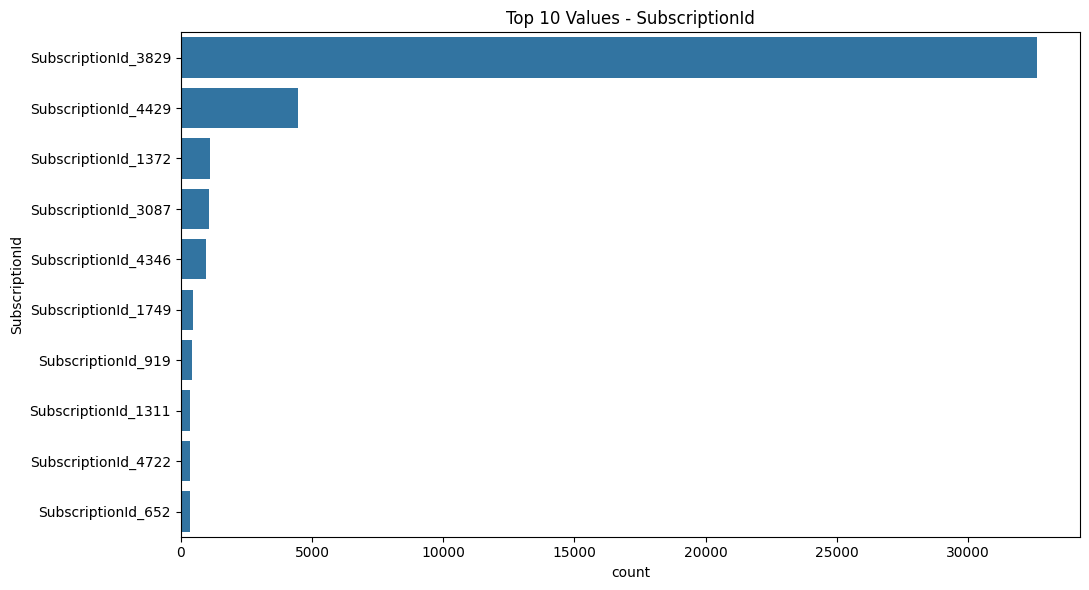

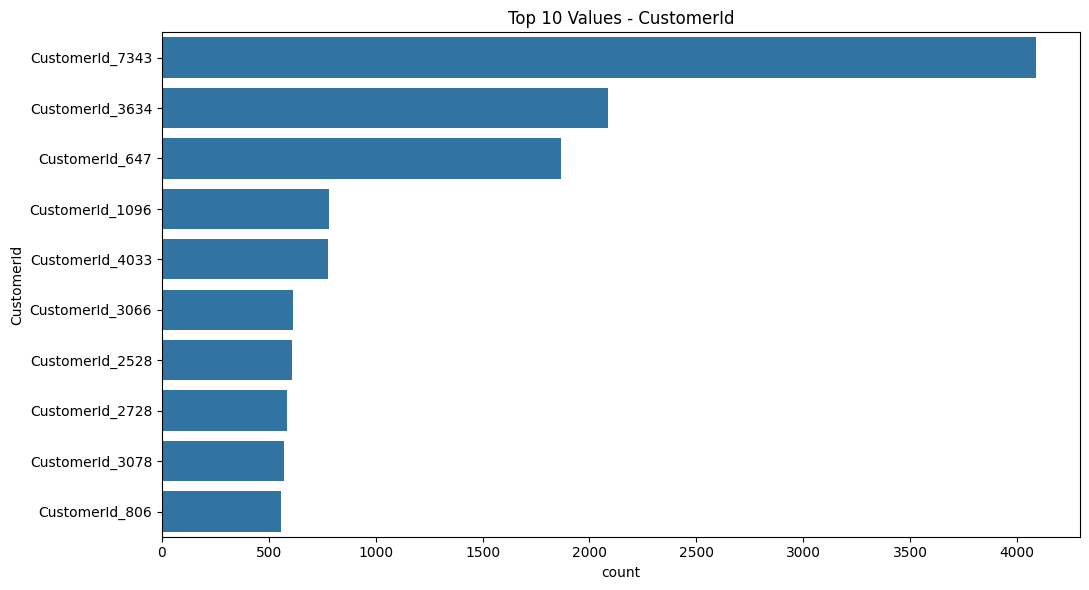

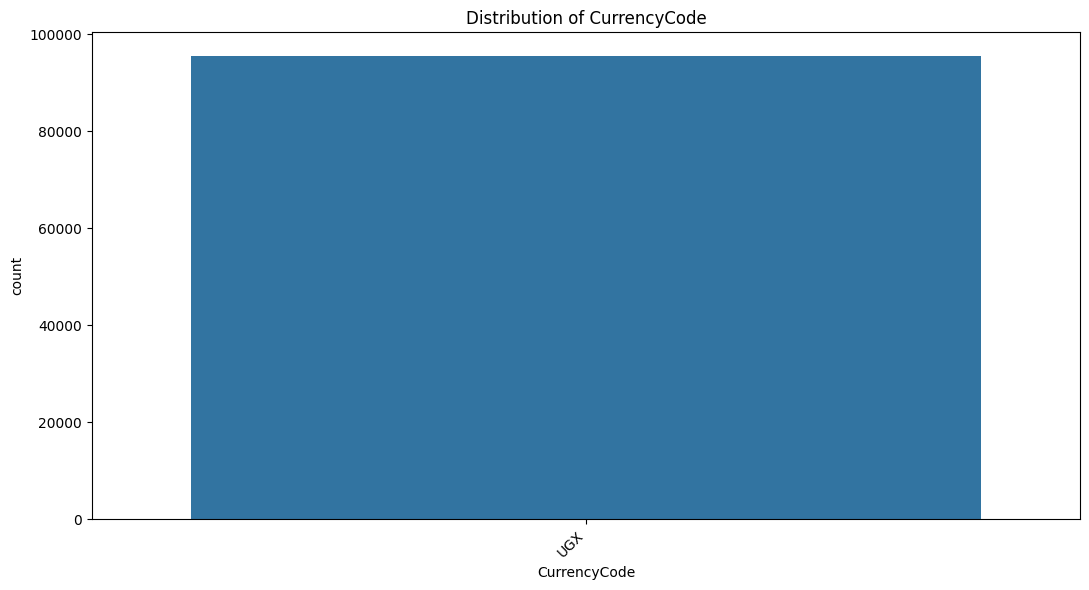

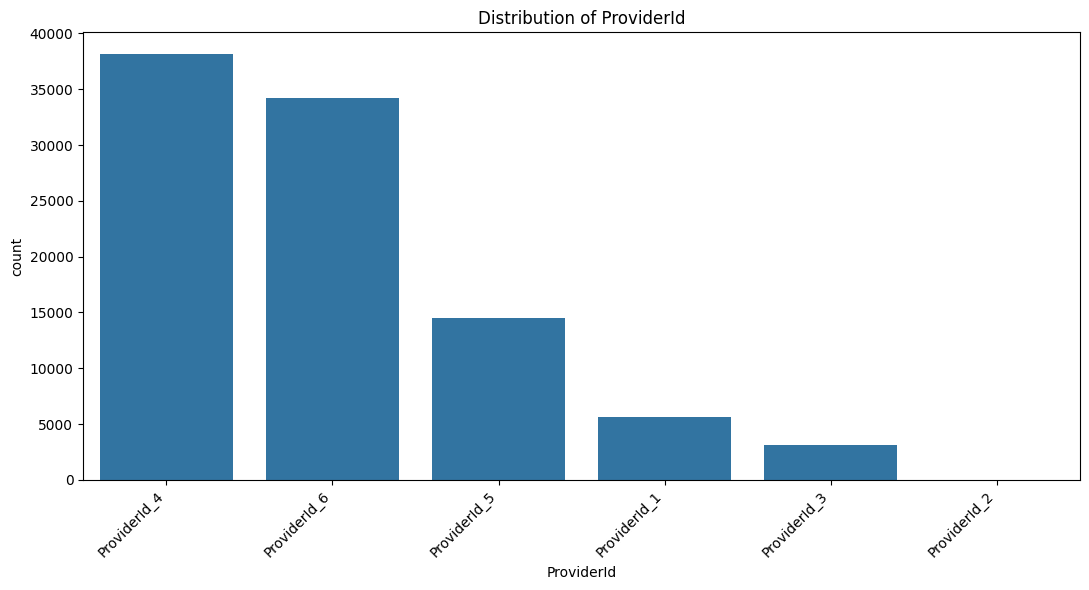

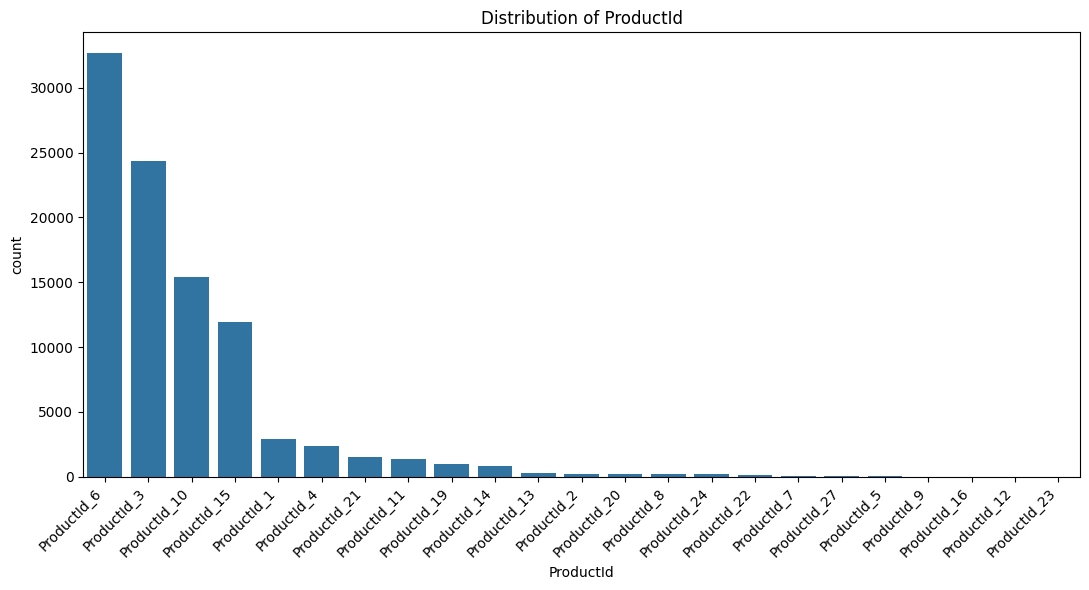

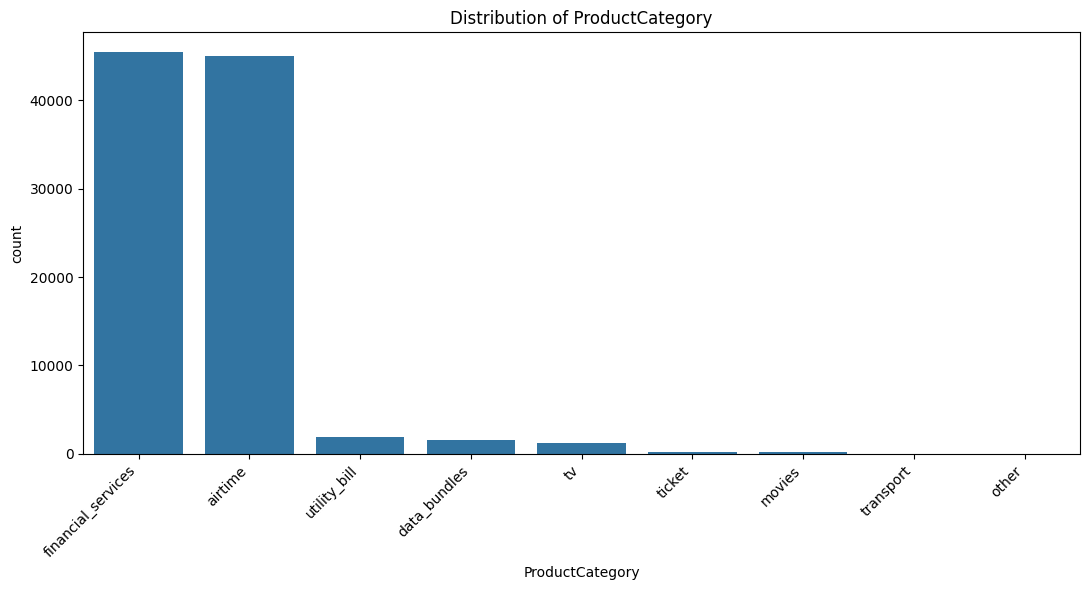

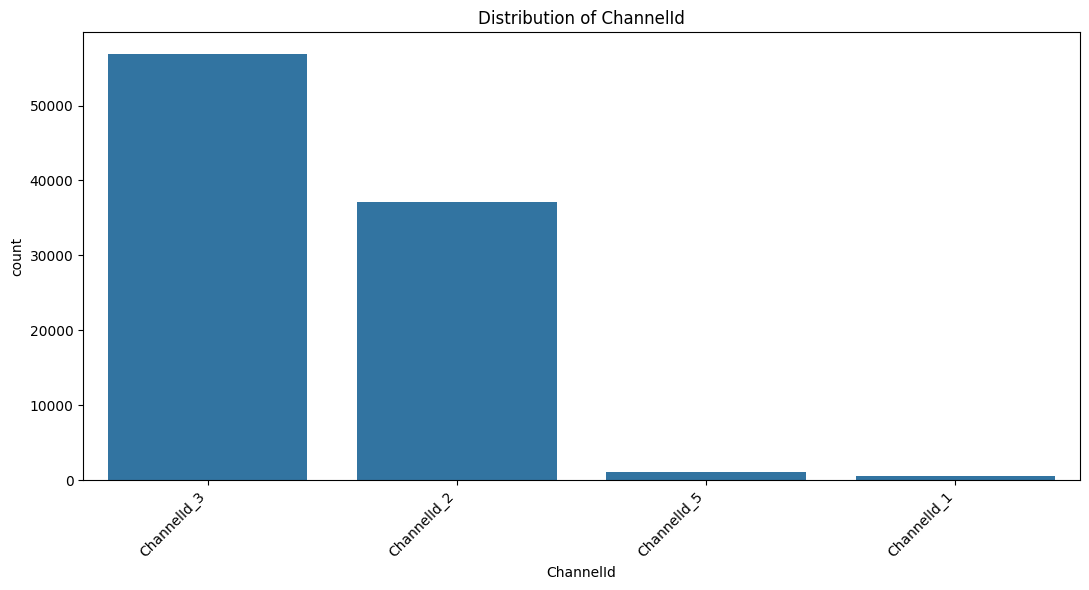

2026-05-31 20:32:41,707 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-31 20:32:41,795 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


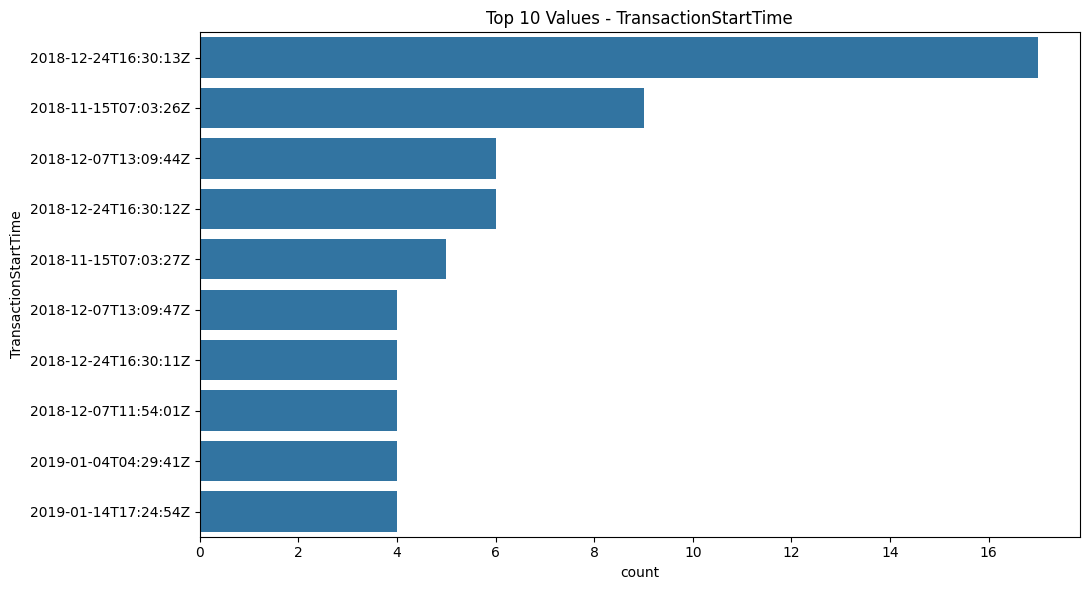

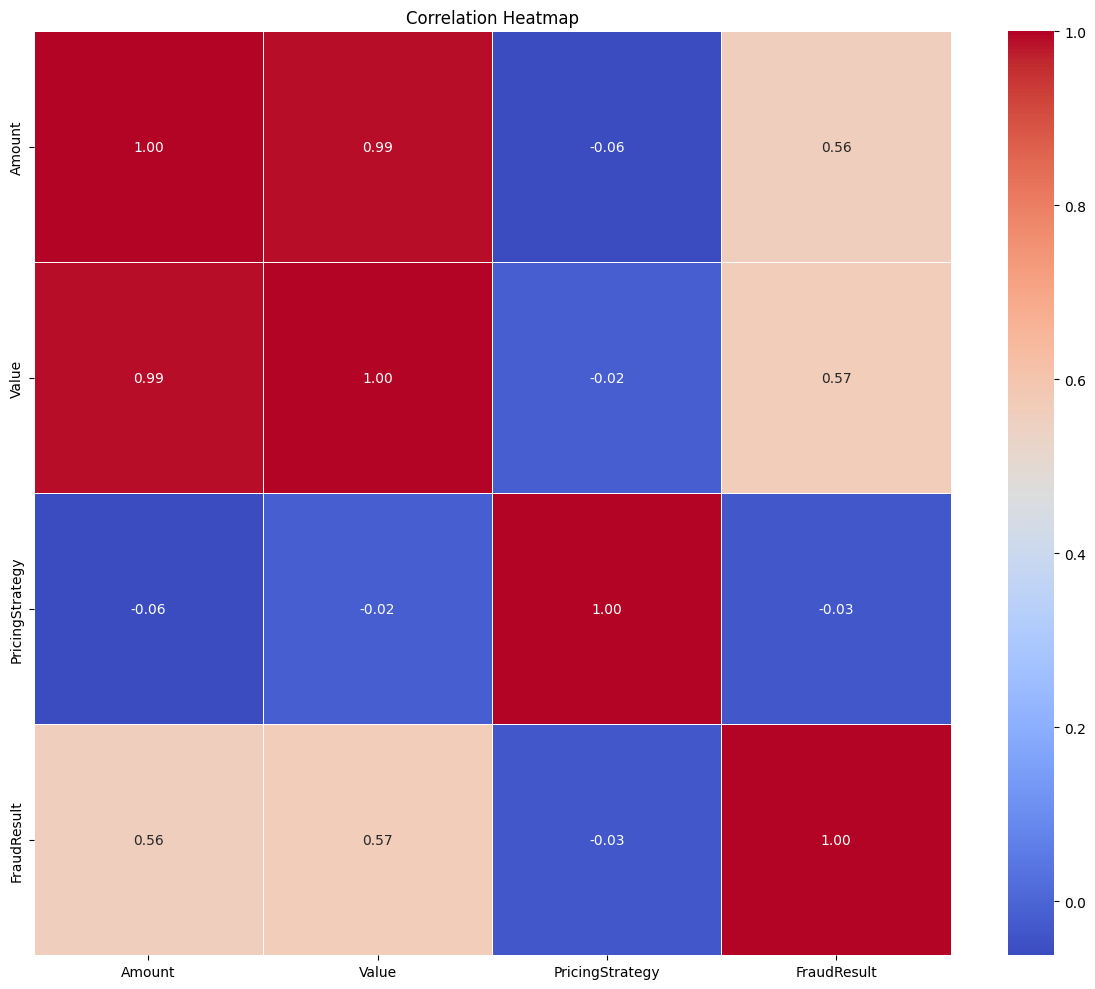

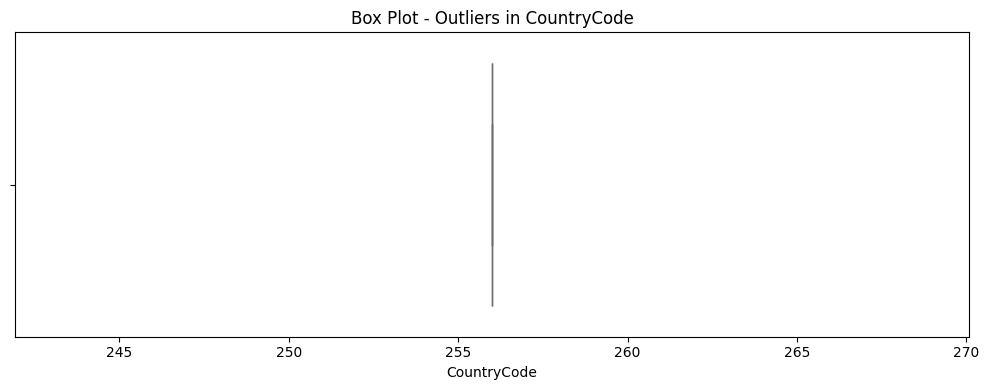

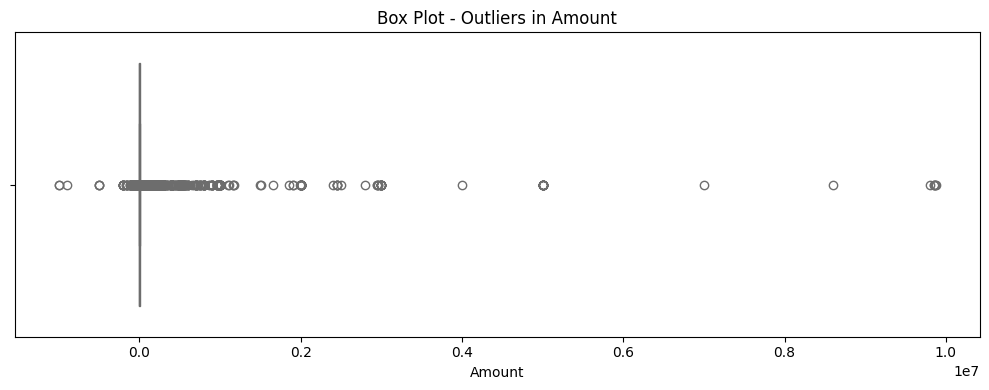

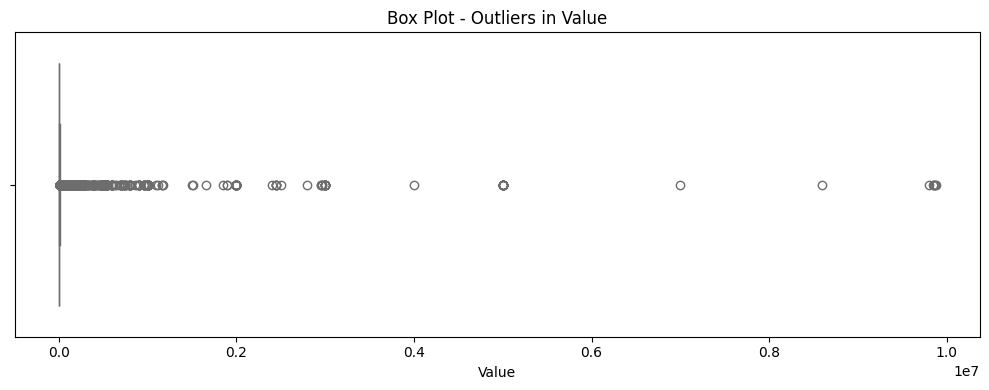

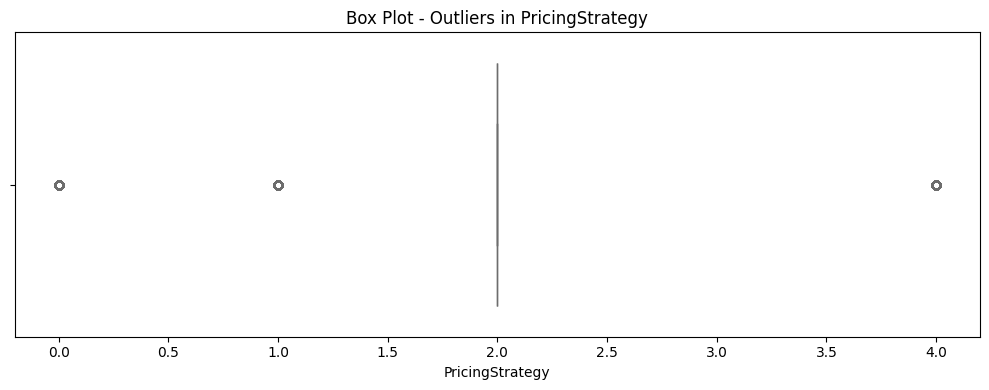

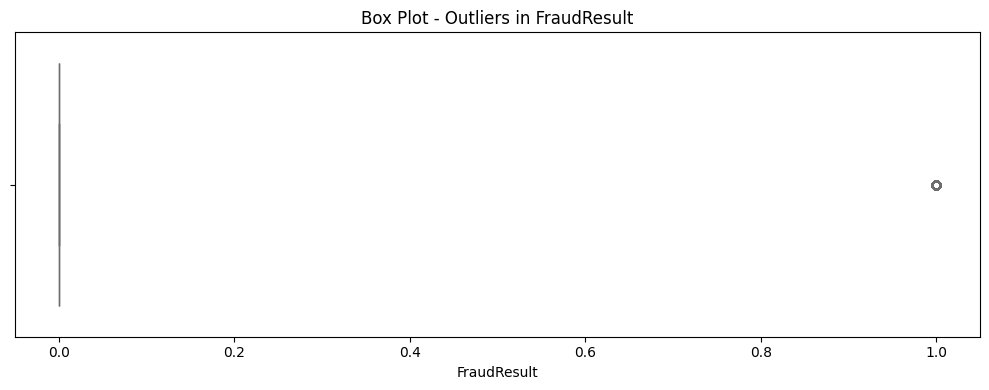

2026-05-31 20:32:48,731 - INFO - Summary report saved: c:\Users\Hello\Desktop\kaim\credit-risk-model\outputs\eda_run_20260531_203220\eda_summary_report.txt
2026-05-31 20:32:48,735 - INFO -  Configuration saved: c:\Users\Hello\Desktop\kaim\credit-risk-model\outputs\eda_run_20260531_203220\config.json
2026-05-31 20:32:48,738 - INFO -  EDA Pipeline completed successfully!


EDA Completed! Check the output folder.


In [16]:
config = EDAConfig(
        sample_size=None,  
        save_plots=True,
        include_plots=True,
        verbose=True
    )
    
pipeline = EDAPipeline(config)
    
results = (pipeline
               .load_data(df)
               .run())
    
print("EDA Completed! Check the output folder.")

### EDA Report: Credit Risk Modeling Dataset

**Generated on:** 30 May 2026  
**Dataset Size:** 95,662 rows × 16 columns  
**Memory Usage:** 74.51 MB  
**Missing Values:** None (Clean dataset)


#### Executive Summary

This EDA reveals a highly skewed financial dataset dominated by **extreme outliers** in monetary variables (`Amount` and `Value`). The target variable `FraudResult` is highly imbalanced, which is typical in fraud detection problems. Several features show characteristics that will require careful preprocessing before modeling.


#### Top 5 Key Insights

 1. **Extreme Right-Skewness in Monetary Features**
- `Amount` and `Value` exhibit extremely high positive skewness (**51.10** and **51.29** respectively) and very high kurtosis (> 3360).
- This indicates a heavy concentration of small/medium transactions with a few extremely large outliers.
- **Recommendation:** Strong transformation (e.g., log, box-cox, or robust scalers) is necessary.

 2. **High Outlier Prevalence**
- `Amount`: **25.55%** outliers
- `PricingStrategy`: **16.53%** outliers  
- `Value`: **9.43%** outliers
- These high outlier percentages confirm the heavy-tailed nature of the data.
- **Recommendation:** Investigate whether these outliers are legitimate high-value transactions or data errors. 

 3. **Severe Class Imbalance in FraudResult**
- Mean of `FraudResult` = **0.002** (only ~0.2% fraudulent cases).
- Very high skewness (**22.20**) and kurtosis (**490.69**).
- **Recommendation:** Use appropriate techniques for imbalanced classification (SMOTE, class weights, undersampling, or anomaly detection approaches).

 4. **Constant Feature - CountryCode**
- `CountryCode` is constant, has zero variance (mean = median = 256.0, std = 0).
- This feature provides **no predictive value**.
- **Recommendation:** Drop this column during preprocessing.

 5. **Strong Correlation Between Amount and Value**
- `Amount` and `Value` show high correlation.
- This suggests they carry very similar information (possibly `Value` is derived from or closely related to `Amount`).
- **Recommendation:** Check for multicollinearity. Consider keeping only one of them or creating new derived features.



#### Summary Statistics (Numeric Features)

| Feature            | Mean         | Median   | Std Dev       | Skewness   | Kurtosis    | Insight                          |
|--------------------|--------------|----------|---------------|------------|-------------|----------------------------------|
| CountryCode        | 256.00       | 256.0    | 0.00          | 0.00       | 0.00        | Symmetric                        |
| Amount             | 6,717.85     | 1,000.0  | 123,306.80    | 51.10      | 3,363.13    | Highly right-skewed + Leptokurtic |
| Value              | 9,900.58     | 1,000.0  | 123,122.09    | 51.29      | 3,378.07    | Highly right-skewed + Leptokurtic |
| PricingStrategy    | 2.26         | 2.0      | 0.73          | 1.66       | 2.09        | Highly right-skewed              |
| FraudResult        | 0.002        | 0.0      | 0.045         | 22.20      | 490.69      | Highly right-skewed + Leptokurtic |

---

## Outlier Analysis

- **Highest Outlier Rate:** `Amount` (25.55%)
- **Moderate:** `PricingStrategy` (16.53%)
- **Lower but notable:** `Value` (9.43%)


**Full artifacts** (plots, config, and detailed report) are available in the generated output folder:
`outputs/`
